## **Carregar Arquivos CSV com o `pandas`**

Agora que temos os arquivos CSV, vamos carregá-los no `pandas` e realizar algumas análises


In [1]:

import pandas as pd

vendas = pd.read_csv('vendas.csv')
produtos = pd.read_csv('produtos.csv')

print(vendas)
print(produtos)


   id_venda  id_produto  id_cliente  quantidade  preco_unitario  data_venda
0         1         101           1           3              20  2025-01-01
1         2         102           2           5              15  2025-01-02
2         3         103           1           2              25  2025-01-03
3         4         101           3           1              20  2025-01-04
4         5         102           2           4              15  2025-01-05
5         6         103           3           3              25  2025-01-06
6         7         101           4           6              20  2025-01-07
7         8         102           4           2              15  2025-01-08
8         9         104           5          10              35  2025-02-22
9        10         104           3           8              35  2025-02-23
   id_produto nome_produto    categoria
0         101    Produto A  Eletrônicos
1         102    Produto B       Roupas
2         103    Produto C    Alimentos
3   


## **Análises e Visualizações**
#### **Total de Vendas por produto**

Vamos calcular o total de vendas por prduto. Para isso vamos juntar os dados de vendas com os dados de produtos usando a chave `id_produto` e deposi somar as vendas.


In [2]:
#Merge entre bvendas e produtos
vendas_com_produto = vendas.merge(produtos, on='id_produto')

#Calcular o total de vendas por produto(quantidade * preco_unitário)

vendas_com_produto['valor_total'] = vendas_com_produto['quantidade'] * vendas_com_produto['preco_unitario']
#Agrupar por produto e calcular o total de vendas
total_vendas_por_produto = vendas_com_produto.groupby('nome_produto')['valor_total'].sum()
print(total_vendas_por_produto)

nome_produto
Produto A    200
Produto B    165
Produto C    125
Produto D    630
Name: valor_total, dtype: int64


#### **Grafico 1:Total de Vendas por Produto**
Vamos criar um gráfico de barras para vizualizar o total de vendas por produtos

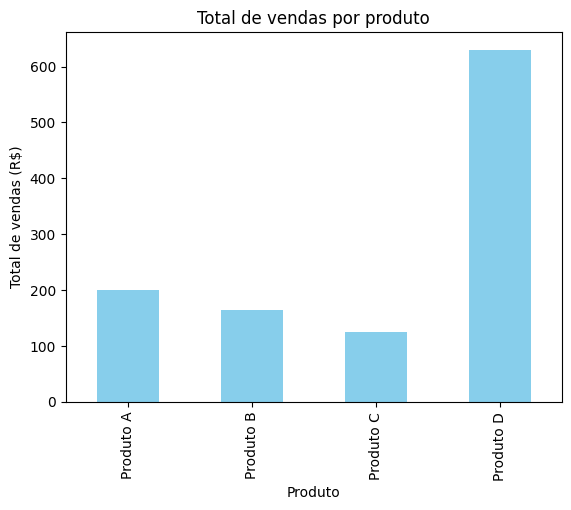

In [3]:

import matplotlib.pyplot as plt

total_vendas_por_produto.plot(kind='bar', color='skyblue', title='Total de vendas por produto')
plt.xlabel('Produto')
plt.ylabel('Total de vendas (R$)')
plt.show()

#### **Análise 2: Média de vendas por Mês**

Agora, vamos analisar a média de vendas por mês. Para isso, vamos usar a coluna `data_venda` para extrair o mês e calcular a média de vendas

In [4]:
#Converter a coluna data_venda para o tipo datetime
vendas['data_venda'] = pd.to_datetime(vendas['data_venda'])

#Extrair o mês de cada venda
vendas['mes'] = vendas['data_venda'].dt.month

#Calcular o total de vendas por mês
vendas['valor_total'] = vendas['quantidade'] * vendas['preco_unitario']
media_vendas_por_mes = vendas.groupby('mes')['valor_total'].mean()

print(media_vendas_por_mes)

mes
1     61.25
2    315.00
Name: valor_total, dtype: float64


#### **Gráfico 2:Média de Vendas por Mês**

Agora, vamos criar um gráfico de linha para vozualizar a média de vendas por mês

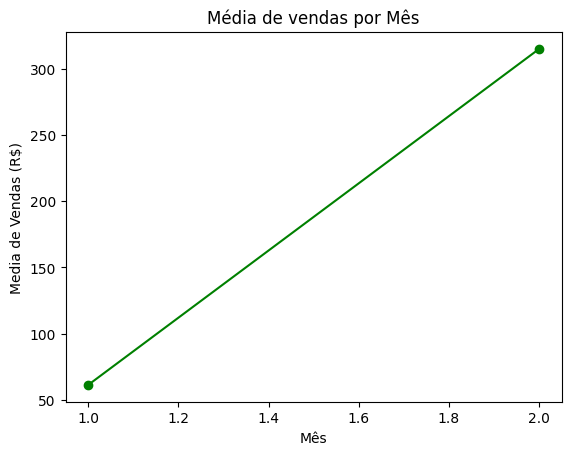

In [5]:
media_vendas_por_mes.plot(kind='line', marker='o', color='green', title='Média de vendas por Mês')
plt.xlabel('Mês')
plt.ylabel('Media de Vendas (R$)')
plt.show()

#### **Análise 3: Vendas por Categoria de Produto**

Agora vamos calcular as vendas totais por categoria de produto. Para isso, usaremos o merge npovemente.

In [6]:
vendas_com_produtos = vendas.merge(produtos, on='id_produto')

vendas_com_produtos['valor_total'] = vendas_com_produtos['quantidade'] * vendas_com_produtos['preco_unitario']
total_vendas_por_categoria = vendas_com_produtos.groupby('categoria')['valor_total'].sum()

print(total_vendas_por_categoria)

categoria
Alimentos      125
Eletrônicos    200
Móveis         630
Roupas         165
Name: valor_total, dtype: int64


### **Gráfico 3: Vendas por Categoria de Produto**

Vamos criar um gráfico de pizza para visualizar a distribuição de vendas por categoria

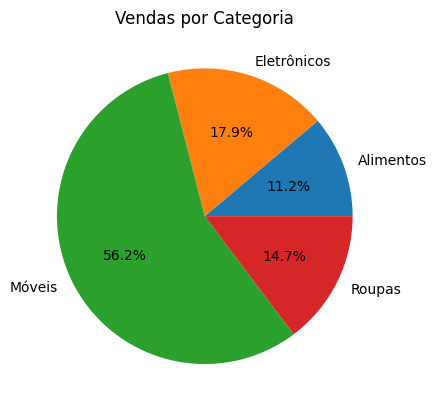

In [7]:
total_vendas_por_categoria.plot(kind='pie', autopct = '%1.1f%%', title = 'Vendas por Categoria')
plt.ylabel('')#Remove a label do eixo y para uma aparência mais limpa
plt.show()

### **Salvar os Gráficos em Arquivos**

Para finalizar, podemos salvar os gráficos gerads em arquivos PNG.

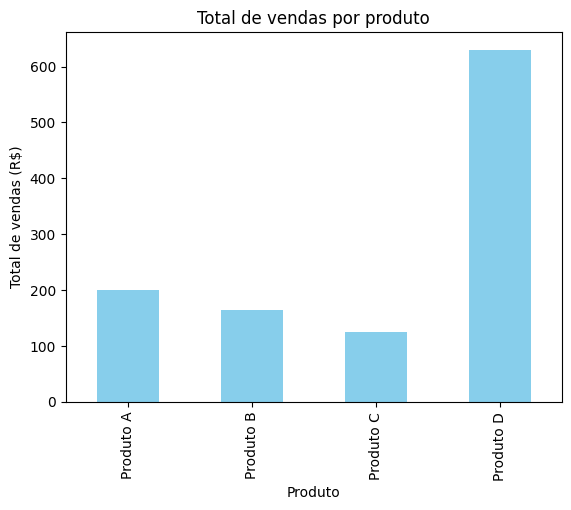

In [8]:
total_vendas_por_produto.plot(kind='bar', color='skyblue', title='Total de vendas por produto')
plt.xlabel('Produto')
plt.ylabel('Total de vendas (R$)')
plt.savefig('grafico_vendas_por_produto.png')

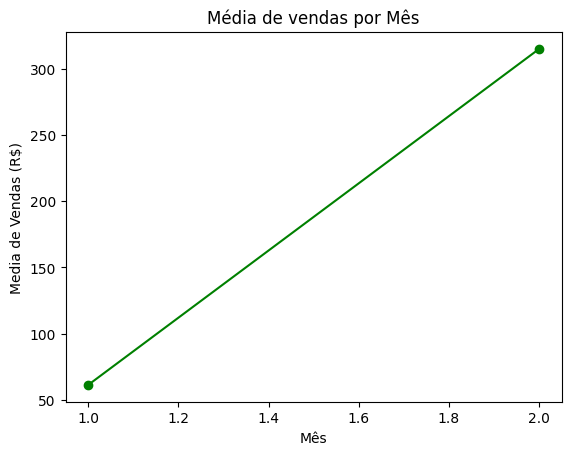

In [9]:
media_vendas_por_mes.plot(kind='line', marker='o', color='green', title='Média de vendas por Mês')
plt.xlabel('Mês')
plt.ylabel('Media de Vendas (R$)')
plt.savefig('grafico_media_vendas_por_mes.png')

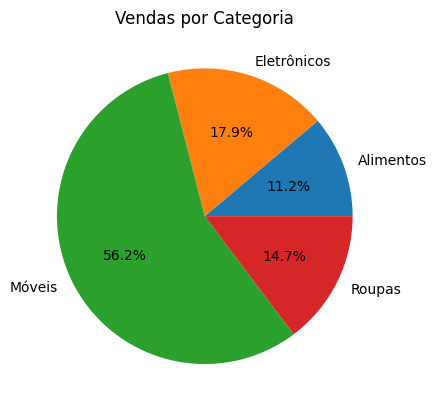

In [10]:
total_vendas_por_categoria.plot(kind='pie', autopct = '%1.1f%%', title = 'Vendas por Categoria')
plt.ylabel('')#Remove a label do eixo y para uma aparência mais limpa
plt.savefig('grafico_vendas_por_categoria.png')

##  **Conclusão**

Neste exercício, você;

1.**Criou arquios CSV** com dados fictícios de vendas e produtos

2. **Carregou os dados** usando `pandas`

3. **Realizou análises** como o total de vendas por produto, a média de vendas por mês e vendas por 
categoria

4. **Gerou gráficos** usando `matplotlib` para vizualizar os resultados dessas análises

5. **Salvou os gráficos** em arquivos PNG

isso cobre a integração entre `pandas` e `matplotlib` para análise e visualização de dados com dados reais em formato CSV!